In [29]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import rv_histogram

import src
from src.reload import deep_reload

In [30]:
outline = gpd.read_file('../google_charger_data/Data/State/tl_2023_us_state.shp')

In [31]:
'''
Loading Atlas
'''

atlas = src.graph.graph_from_json('Inputs/reduced_atlas.json')

In [32]:
'''
Loading stations
'''

graph = src.graph.graph_from_json('Outputs/graph.json')

In [33]:
'''
Loading groups
'''
deep_reload(src)

groups, counts = src.sample.load_groups('Inputs/sampling_rules.csv')

graph = src.sample.assign_groups(graph, groups)

totals = {k: 0 for k in counts.keys()}

for source, node in graph._node.items():

    if node['group'] is not None:

        totals[node['group']] += 1

adjusted_counts = {k: min([totals[k], counts[k]]) for k in totals.keys()}

In [34]:
'''
Building the cost matrix
'''
deep_reload(src)

depots = [k for k, v in graph._node.items() if v['network'] == 'Depot']

graph = src.sample.station_costs(graph, atlas, depots, objective = 'time')

In [35]:
'''
Optimizing the sample
'''
deep_reload(src)

opt = src.sample.Optimization(graph, adjusted_counts)

solver_kwargs = {'_name': 'cbc', 'executable': 'src/cbc'}
# solver_kwargs = {'_name': 'appsi_highs'}

opt.solve(**solver_kwargs)

Problem Built: 1.1056194305419922
Problem Solved: 2.4275918006896973
Results Collected: 0.0317690372467041


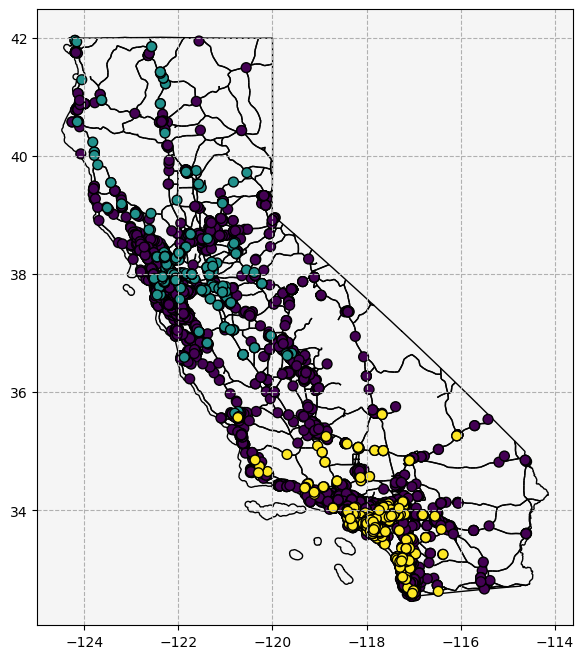

In [37]:
fig, ax = plt.subplots(figsize = (8, 8))

kw = {
    'fc': 'none',
    'ec': 'k',
}

_ = outline[outline['STATEFP'] == '06'].plot(ax = ax, **kw)

kw = {
    'edges': {
        'plot':{
            'lw': 1,
            'color': 'k',
            'zorder': 0,
        },
    },
}

plots = src.figures.plot_graph(atlas, ax = ax, **kw)

for source, node in graph._node.items():

    # print(source, opt.assignment.get(int(source), 0) + 1)

    node['assignment'] = int(opt.assignment.get(source, 0)) / 2
    # print(node['assignment'])

kw = {
    'nodes': {
        'field': 'assignment',
        'plot': {
            's': 50,
            'ec': 'k',
            'zorder': 1,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)


kw = {
    'facecolor': 'whitesmoke',
}

ax.set(**kw)

kw = {
    'ls': 'dashed',
}

ax.grid(**kw)

fig.savefig('new_sample.png', bbox_inches = 'tight', dpi = 300)

In [38]:
'''
Making subgraphs
'''
deep_reload(src)

subgraphs = src.sample.subgraphs(graph, opt.assignment)

In [39]:
[(s.number_of_nodes(), s.number_of_edges()) for s in subgraphs.values()]

[(368, 0), (895, 0)]

In [47]:
'''
Adding adjacency
'''
deep_reload(src)

kw = {
    'maximum_cost': 400e3,
    'maximum_depth': 400e3,
    'depots': list(subgraphs.keys()),
}

for depot, subgraph in subgraphs.items():

    subgraph = src.adjacency.adjacency(atlas, subgraph, **kw)
    # break

 [--------->] (895/895) 100.00%, 41.55 it/s, 21.56 s elapsed, 0.00 s remaining

In [45]:
cc = list(nx.connected_components(subgraphs[1]))
len(cc)

1

In [43]:
len(subgraphs[1]._adj[1])

368

In [44]:
len(subgraphs[2]._adj[2])

895

In [46]:
list(subgraphs.keys())

[1, 2]

In [42]:
for depot, subgraph in subgraphs.items():

    src.graph.graph_to_json(subgraph, f"Graphs/subgraph_{depot}.json")

In [43]:
[(s.number_of_nodes(), s.number_of_edges()) for s in subgraphs.values()]

[(584, 120717), (1041, 510298)]